# Классификация, Фильтры, Шум и MNIST

## Импорт библиотек

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import fetch_openml
import time

# Бинарная классификация

In [33]:
data_dir = "."
files = [f for f in os.listdir(data_dir) if f.endswith(('.jpg', '.JPG')) and (f.startswith('cat_') or f.startswith('dog_'))]
files.sort()

print(f"Найдено файлов: {len(files)}")
print(files)

Найдено файлов: 16
['cat_1.jpg', 'cat_2.jpg', 'cat_3.jpg', 'cat_4.jpg', 'cat_5.JPG', 'cat_6.JPG', 'cat_7.JPG', 'cat_8.JPG', 'dog_1.jpg', 'dog_2.jpg', 'dog_3.jpg', 'dog_4.jpg', 'dog_5.JPG', 'dog_6.JPG', 'dog_7.JPG', 'dog_8.JPG']


In [34]:
images = []
for file in files:
    img = cv2.imread(os.path.join(data_dir, file))
    if img is not None:
        images.append(img)

print(f"Загружено изображений: {len(images)}")

Загружено изображений: 16


In [35]:
y = []
for file in files:
    if file.startswith("cat"):
        y.append(1)
    else:
        y.append(0)

print(f"Метки классов: {y}")
print(f"Кошек: {sum(y)}, Собак: {len(y) - sum(y)}")

Метки классов: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Кошек: 8, Собак: 8


### Применение фильтров и детекция границ

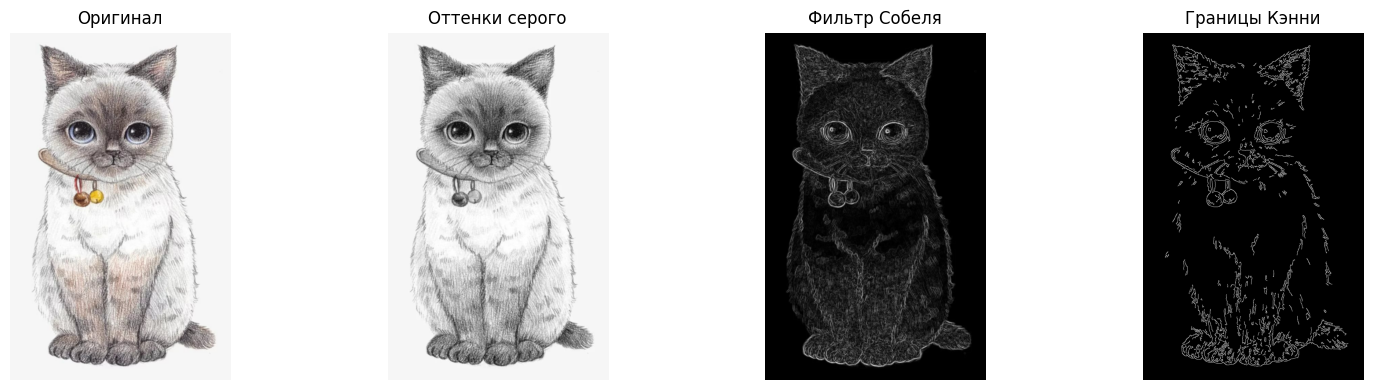

In [36]:
def apply_filters(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    gaussian_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    sobel_x = cv2.Sobel(gaussian_blur, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gaussian_blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    
    edges_canny = cv2.Canny(gaussian_blur, 100, 200)
    
    return gray, gaussian_blur, sobel_magnitude, edges_canny

if len(images) > 0:
    gray, blur, sobel, edges = apply_filters(images[0])
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
    axes[0].set_title('Оригинал')
    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title('Оттенки серого')
    axes[2].imshow(sobel, cmap='gray')
    axes[2].set_title('Фильтр Собеля')
    axes[3].imshow(edges, cmap='gray')
    axes[3].set_title('Границы Кэнни')
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Извлечение признаков и классификация

In [37]:
def extract_features(img):
    img_resized = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    hist = cv2.calcHist([gray], [0], None, [32], [0, 256]).flatten()
    hist = hist / hist.sum()  # Нормализация
    
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    edge_density = np.mean(sobel_mag)
    
    return np.concatenate([hist, [mean_val, std_val, edge_density]])

X = np.array([extract_features(img) for img in images])
y = np.array(y)

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

Размер матрицы признаков: (16, 35)
Количество признаков: 35


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (11, 35)
Тестовая выборка: (5, 35)


In [39]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность на тестовой выборке: {accuracy:.4f}")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred, target_names=['Собаки', 'Кошки']))


Точность на тестовой выборке: 0.2000

Отчёт по классификации:
              precision    recall  f1-score   support

      Собаки       0.33      0.33      0.33         3
       Кошки       0.00      0.00      0.00         2

    accuracy                           0.20         5
   macro avg       0.17      0.17      0.17         5
weighted avg       0.20      0.20      0.20         5



# Добавление шума к изображениям

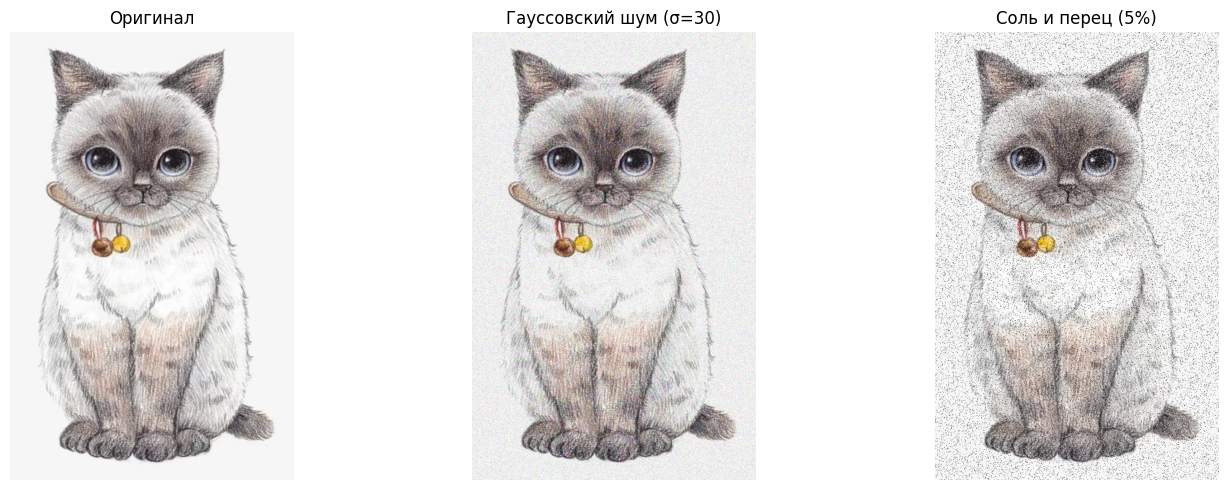

In [40]:
def add_gaussian_noise(img, mean=0, sigma=25):
    img_float = img.astype(np.float32)
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy_img = img_float + noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
    return noisy_img

def add_salt_pepper_noise(img, salt_prob=0.05, pepper_prob=0.05):
    noisy_img = img.copy()
    sp_noise = np.random.rand(*img.shape[:2])
    
    noisy_img[sp_noise < salt_prob] = 255
    
    if len(img.shape) == 3:
        for i in range(img.shape[2]):
            noisy_img[:, :, i][sp_noise > (1 - pepper_prob)] = 0
    else:
        noisy_img[sp_noise > (1 - pepper_prob)] = 0
    
    return noisy_img

if len(images) > 0:
    original = images[0]
    
    noisy_gaussian = add_gaussian_noise(original, mean=0, sigma=30)
    
    noisy_sp = add_salt_pepper_noise(original, salt_prob=0.05, pepper_prob=0.05)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Оригинал')
    axes[1].imshow(cv2.cvtColor(noisy_gaussian, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Гауссовский шум (σ=30)')
    axes[2].imshow(cv2.cvtColor(noisy_sp, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Соль и перец (5%)')
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Классификация зашумленных изображений

In [41]:
images_gaussian = [add_gaussian_noise(img) for img in images]
images_sp = [add_salt_pepper_noise(img) for img in images]

X_gaussian = np.array([extract_features(img) for img in images_gaussian])
X_sp = np.array([extract_features(img) for img in images_sp])

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gaussian, y, test_size=0.3, random_state=42, stratify=y
)

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_sp, y, test_size=0.3, random_state=42, stratify=y
)

In [42]:
print("Классификация с гауссовским шумом")
rf_gaussian = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_gaussian.fit(X_train_g, y_train_g)
y_pred_g = rf_gaussian.predict(X_test_g)
print(f"Точность (Гауссовский шум): {accuracy_score(y_test_g, y_pred_g):.4f}")

print("Классификация с шумом 'соль и перец'")
rf_sp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_sp.fit(X_train_sp, y_train_sp)
y_pred_sp = rf_sp.predict(X_test_sp)
print(f"Точность (Соль и перец): {accuracy_score(y_test_sp, y_pred_sp):.4f}")

print("Сравнение результатов")
print(f"Оригинальные изображения:     {accuracy:.4f}")
print(f"Гауссовский шум:              {accuracy_score(y_test_g, y_pred_g):.4f}")
print(f"Соль и перец:                 {accuracy_score(y_test_sp, y_pred_sp):.4f}")

Классификация с гауссовским шумом
Точность (Гауссовский шум): 0.6000
Классификация с шумом 'соль и перец'
Точность (Соль и перец): 0.4000
Сравнение результатов
Оригинальные изображения:     0.2000
Гауссовский шум:              0.6000
Соль и перец:                 0.4000


# Многоклассовая классификация на данных MNIST

In [43]:
mnist = fetch_openml('Fashion-MNIST', version=1, parser='auto', as_frame=False)
X_mnist = mnist.data
y_mnist = mnist.target.astype(int)

print(f"Размер данных: {X_mnist.shape}")
print(f"Классы: {np.unique(y_mnist)}")

X_mnist = X_mnist / 255.0

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.2, random_state=42, stratify=y_mnist
)

print(f"\nОбучающая выборка: {X_train_mnist.shape}")
print(f"Тестовая выборка: {X_test_mnist.shape}")

Размер данных: (70000, 784)
Классы: [0 1 2 3 4 5 6 7 8 9]

Обучающая выборка: (56000, 784)
Тестовая выборка: (14000, 784)


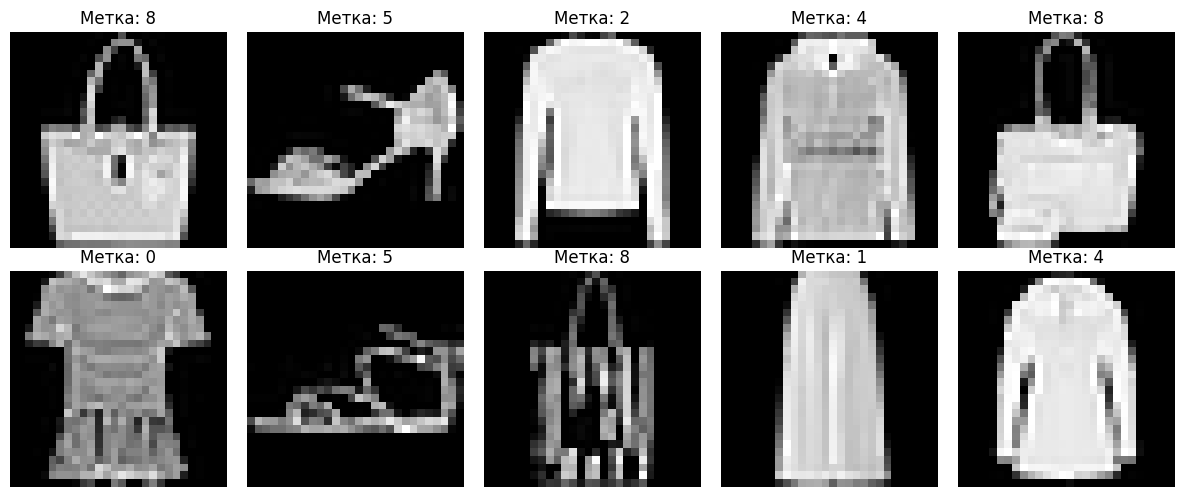

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_mnist))
    img = X_mnist[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Метка: {y_mnist[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [45]:
start_time = time.time()

rf_mnist = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_mnist.fit(X_train_mnist, y_train_mnist)
print(f"Обучение завершено за {time.time() - start_time:.2f} сек")

y_pred_mnist = rf_mnist.predict(X_test_mnist)

accuracy_mnist = accuracy_score(y_test_mnist, y_pred_mnist)
print(f"\nТочность на тестовой выборке: {accuracy_mnist:.4f}")

print("\nОтчёт по классификации:")
print(classification_report(y_test_mnist, y_pred_mnist))

Обучение завершено за 4.99 сек

Точность на тестовой выборке: 0.8796

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1400
           1       0.99      0.96      0.98      1400
           2       0.79      0.81      0.80      1400
           3       0.87      0.92      0.90      1400
           4       0.77      0.84      0.80      1400
           5       0.97      0.96      0.97      1400
           6       0.72      0.57      0.64      1400
           7       0.94      0.94      0.94      1400
           8       0.97      0.96      0.97      1400
           9       0.95      0.96      0.95      1400

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



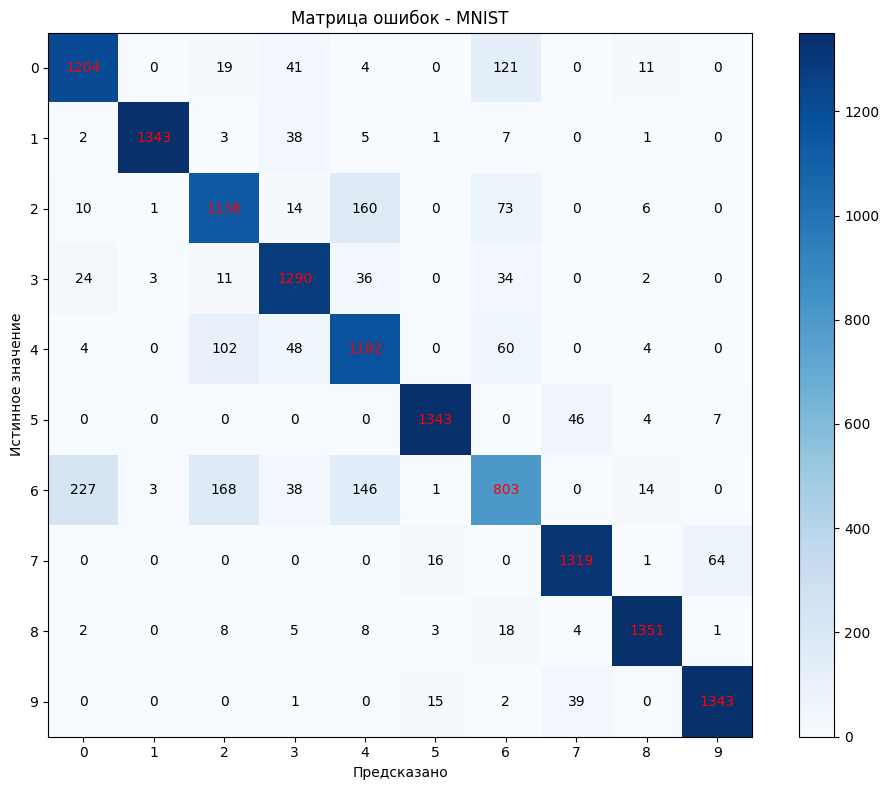

In [46]:
cm = confusion_matrix(y_test_mnist, y_pred_mnist)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок - MNIST')
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

### Классификация MNIST с шумом

In [47]:
def add_noise_to_mnist(X, noise_level=0.1):
    noise = np.random.normal(0, noise_level, X.shape)
    X_noisy = X + noise
    X_noisy = np.clip(X_noisy, 0, 1)
    return X_noisy

X_test_mnist_noisy = add_noise_to_mnist(X_test_mnist, noise_level=0.3)

y_pred_noisy = rf_mnist.predict(X_test_mnist_noisy)
accuracy_noisy = accuracy_score(y_test_mnist, y_pred_noisy)

print(f"Точность на чистых данных:    {accuracy_mnist:.4f}")
print(f"Точность на зашумленных данных: {accuracy_noisy:.4f}")
print(f"Падение точности:             {(accuracy_mnist - accuracy_noisy):.4f}")

Точность на чистых данных:    0.8796
Точность на зашумленных данных: 0.4976
Падение точности:             0.3820


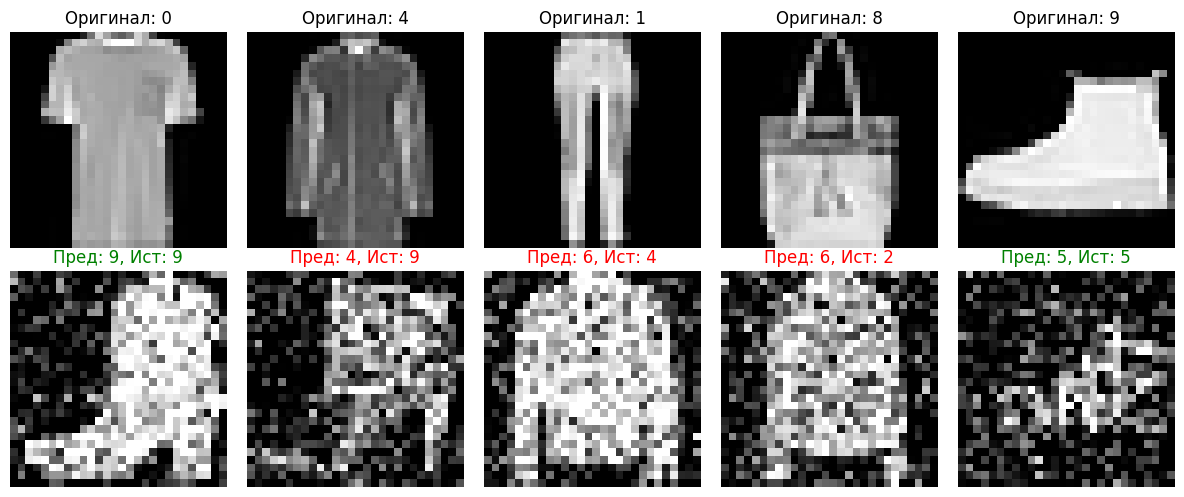

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes[0].flat):
    idx = np.random.randint(0, len(X_test_mnist))
    img = X_test_mnist[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Оригинал: {y_test_mnist[idx]}')
    ax.axis('off')

for i, ax in enumerate(axes[1].flat):
    idx = np.random.randint(0, len(X_test_mnist_noisy))
    img = X_test_mnist_noisy[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    pred = y_pred_noisy[idx]
    true = y_test_mnist[idx]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Пред: {pred}, Ист: {true}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ИТОГИ

In [49]:
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("1. Бинарная классификация (Cats vs Dogs):")
print(f"   - Оригинальные изображения:  {accuracy:.4f}")
print(f"   - Гауссовский шум:           {accuracy_score(y_test_g, y_pred_g):.4f}")
print(f"   - Соль и перец:              {accuracy_score(y_test_sp, y_pred_sp):.4f}")
print()
print("2. Многоклассовая классификация (MNIST):")
print(f"   - Чистые данные:             {accuracy_mnist:.4f}")
print(f"   - Зашумленные данные:        {accuracy_noisy:.4f}")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
1. Бинарная классификация (Cats vs Dogs):
   - Оригинальные изображения:  0.2000
   - Гауссовский шум:           0.6000
   - Соль и перец:              0.4000

2. Многоклассовая классификация (MNIST):
   - Чистые данные:             0.8796
   - Зашумленные данные:        0.4976
